# Finite-sample train/test loss convergence for shallow masked diffusion

This notebook is a finite-dimensional empirical sanity check. It is not a proof, not a thermodynamic-limit calculation, not a replica derivation, and not a generative sampling evaluation.

## Professor's problem notation

We fix a latent dimension $D$. For each experiment, we choose

$$
\gamma = \frac{N}{D}, 
\qquad 
\alpha = \frac{M}{D},
$$

where:

- $D$ is the latent dimension;
- $N$ is the visible binary sequence length;
- $M$ is the number of training samples;
- $\gamma$ controls the visible dimension relative to the latent dimension;
- $\alpha$ controls the sample load relative to the latent dimension.

The data are generated from a random-feature / hidden-manifold model:

$$
F_{ij} \sim \mathcal N\left(0,\frac{1}{D}\right),
\qquad
F \in \mathbb R^{N \times D},
$$

$$
z^\mu \sim \mathcal N(0,I_D),
\qquad
x^\mu = \operatorname{sign}(Fz^\mu)\in\{-1,+1\}^N,
\qquad
\mu=1,\dots,M.
$$

The shallow masked diffusion model predicts masked coordinates from the visible coordinates. For a masked coordinate $i$, under the linear backbone model configuration used in this notebook (`freeze_mask_weights=True` and `bias=False`):

$$
\operatorname{logit}_i(x_t) = \sum_{j=1}^N W_{\mathrm{code}}[i,j] x_{t,j}
$$

where $x_{t,j} \in \{-1, 0, +1\}$, where 0 is the mask token. The full `LinearBackbone` also has a mask-indicator term $V$, but $V$ is frozen at zero here.

We vary the sample load $\alpha=M/D$ and visible-to-latent ratio $\gamma=N/D$ at fixed $D$.


## Translation to the codebase

The professor's notation is not identical to the repository notation.

In the codebase:

$$
L = N,
$$

because the masked diffusion model acts on binary vectors of length $N$. The repository's training argument `alpha` means

$$
\alpha_{\mathrm{code}} = \frac{M_{\mathrm{train}}}{N}.
$$

Therefore, when the professor's parameters are

$$
\alpha_{\mathrm{prof}} = \frac{M}{D},
\qquad
\gamma = \frac{N}{D},
$$

the codebase value `alpha_code` must be

$$
\alpha_{\mathrm{code}}
=
\frac{M_{\mathrm{train}}}{N}
=
\frac{\alpha_{\mathrm{prof}} D}{\gamma D}
=
\frac{\alpha_{\mathrm{prof}}}{\gamma}.
$$

In the notebook, the variable `sample_load` represents the professor's $\alpha_{\mathrm{prof}} = M/D$, which is distinct from the repository's `alpha` parameter.
Thus, in the notebook we use:

$$
N = \operatorname{round}(\gamma D),
\qquad
M_{\mathrm{train}} = \operatorname{round}(\text{sample\_load} \cdot D),
\qquad
\alpha_{\mathrm{code}} = \frac{M_{\mathrm{train}}}{N}.
$$

### Notation Mapping Table

| Professor notation | Meaning                    | Code variable                 |
| ------------------ | -------------------------- | ----------------------------- |
| $D$                | latent dimension           | `D` or `n_hidden`             |
| $N$                | visible binary dimension   | `N`, also `L` in model        |
| $M$                | number of training samples | `M_train`                     |
| $\gamma=N/D$       | visible-to-latent ratio    | `gamma`                       |
| $\alpha_{\mathrm{prof}}=M/D$ | sample load      | `sample_load`                 |
| $\alpha_{\mathrm{code}}=M/N$ | repository training ratio | `alpha_code`        |


## Imports

We import standard numerical libraries, PyTorch, PyTorch Lightning, and the classes `RandomFeaturesDataset` and `MaskedDiffusion` from our codebase.


In [1]:
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from types import SimpleNamespace
from torch.utils.data import Subset, DataLoader
from pathlib import Path

# Robust path logic: find the project root directory containing datasets.py and diffusion.py
current_dir = Path.cwd()
project_root = None
for path in [current_dir, current_dir.parent] + list(current_dir.parents):
    if (path / "datasets.py").exists() and (path / "diffusion.py").exists():
        project_root = path.resolve()
        break

if project_root is None:
    raise FileNotFoundError("Could not find project root containing datasets.py and diffusion.py")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from datasets import RandomFeaturesDataset
from diffusion import MaskedDiffusion


## Fixed Parameters

We specify the fixed parameters for the training sweep. We set the latent dimension $D=20$. We define list parameters for the visible-to-latent ratio $\gamma$ (`gamma_values`) and sample load $\alpha$ (`sample_load_values`). The masking probability $t_{\mathrm{mask}}$ is determined by an expected visible context size $K = \text{round}(\kappa \cdot D)$ with $\kappa = 0.5$.


In [2]:
# Fixed Parameter Setup
D = 20  # fixed latent dimension
gamma_values = [1.0, 2.0, 4.0]  # visible ratio N/D (gamma)
sample_load_values = [0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0]  # sample load M/D (professor's alpha)

# Masking setup (expected visible context ratio relative to latent dimension kappa = K/D)
kappa = 0.5
M_test = 1000  # fixed number of test samples
num_steps = 2000  # fixed number of optimizer updates per training run
n_eval_mc = 50  # number of Monte Carlo samples for loss evaluation

# Reproducibility
base_seed = 42
torch.manual_seed(base_seed)
np.random.seed(base_seed)


## Random-Feature Data Generation

For each fixed pair $(D, \gamma)$, we instantiate one `RandomFeaturesDataset` containing a fixed random matrix $F \in \mathbb R^{N \times D}$.

Mathematically, the data generation matches:

$$
x = \operatorname{sign}(z F^\top),
\qquad
F \in \mathbb R^{N \times D},
\qquad
F_{ij} \sim \mathcal N\left(0, \frac{1}{D}\right),
\qquad
z \sim \mathcal N(0, I_D).
$$

In the codebase, the dataset class `RandomFeaturesDataset` constructs $F$ with shape `(n_visible, n_hidden)` and scales it by $D^{-0.5}$, samples $z \in \mathbb R^{M \times n_{\mathrm{hidden}}}$, and returns the sign activation function applied to $z F^\top$. Under the mapping `n_visible = N` and `n_hidden = D`, the dataset instantiation is:

```python
dataset = RandomFeaturesDataset(
    n_visible=N,
    n_hidden=D,
    num_samples=M_train + M_test,
    act=torch.sign,
)
```

For each sample size $M_{\mathrm{train}} = \operatorname{round}(\text{sample\_load} \cdot D)$, we draw the first $M_{\mathrm{train}}$ samples from this dataset. The held-out test set is drawn from the remaining portion of the same dataset pool, which ensures that all points on the curves correspond to the same underlying random feature model configuration.


## Fixed-Step Training Helper

We define a helper function to train the `MaskedDiffusion` model for exactly `num_steps` optimizer updates. This represents a controlled optimization budget, which ensures that models trained on different dataset sizes receive the same optimization updates (avoiding the artifact where larger datasets receive more gradient steps under a fixed epoch regime). In each step:
1. We sample a mini-batch from the training dataset.
2. We compute the masked logistic loss using the codebase function `model._compute_loss(batch, t=t_mask)`.
3. We add the L2 regularization loss configured via `model.l2coeff * model.sqnorm()`.
4. We backpropagate the gradients and update the weights.


In [3]:
def train_model(train_dataset, config, num_steps, t_mask, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)
        
    model = MaskedDiffusion(config)
    # Ensure optimizer is configured
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=0.0)
    
    # Setup data loader
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
    
    model.train()
    step = 0
    iterator = iter(train_loader)
    
    while step < num_steps:
        try:
            batch = next(iterator)
        except StopIteration:
            iterator = iter(train_loader)
            batch = next(iterator)
            
        optimizer.zero_grad()
        # Compute loss at the fixed masking level t_mask
        loss, acc = model._compute_loss(batch, t=t_mask)
        # Add L2 penalty consistent with codebase training step
        total_loss = loss + model.l2coeff * model.sqnorm()
        
        total_loss.backward()
        optimizer.step()
        step += 1
        
    return model


## Evaluation Helper

We define a helper function to evaluate the train or test loss and accuracy on a given dataset. To get a precise estimate of the loss under the chosen Bernoulli masking probability, we compute the expectation over multiple Monte Carlo samples (given by `n_eval_mc`) using the existing `model._compute_loss` method at the masking probability $t_{\mathrm{mask}}$.


In [4]:
@torch.no_grad()
def evaluate_model(model, dataset, mc_samples, t_mask):
    model.eval()
    # Load entire dataset as a single batch for evaluation
    loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)
    batch = next(iter(loader))
    loss, acc = model._compute_loss(batch, t=t_mask, mc_samples=mc_samples)
    return loss.item(), acc


## Sweep over Ratios and Sample Loads

We perform a nested loop over the visible-to-latent ratios $\gamma \in \text{gamma\_values}$ and sample loads $\alpha_{\mathrm{prof}} \in \text{sample\_load\_values}$ at a fixed latent dimension $D = 20$. For each pair $(D, \gamma)$, we generate a single fixed random-feature dataset pool.

For each sample load $\alpha_{\mathrm{prof}}$, we construct a training subset containing the first $M_{\mathrm{train}} = \text{round}(\alpha_{\mathrm{prof}} \cdot D)$ samples, configure the model, train it for exactly `num_steps` updates, and evaluate the train and test losses.

### Bernoulli Masking and Visible Context Size

The masking level $t_{\mathrm{mask}}$ is computed such that the expected visible context size is $K = \text{round}(\kappa \cdot D)$. Under Bernoulli masking:
- Each coordinate is masked independently with probability $t_{\mathrm{mask}} = 1 - K/N$.
- The expected number of visible coordinates is $N(1 - t_{\mathrm{mask}}) = K$.
- The actual count of visible coordinates fluctuates around $K$ following a binomial distribution.

We add runtime guards to assert:
1. $0 < K < N$
2. $0 < t_{\mathrm{mask}} < 1$
3. $M_{\mathrm{train}} > 0$
4. The dataset contains only binary values in $\{-1, 1\}$.


In [5]:
# Run the training sweep over gamma and sample_load values with reproducibility and assertions
results_list = []

for gamma in gamma_values:
    # Compute visible dimension and max sample size for this (D, gamma)
    N = int(round(gamma * D))
    M_max = int(round(max(sample_load_values) * D))
    
    # Calculate masking level corresponding to K expected visible coordinates
    K = int(round(kappa * D))
    t_mask_val = 1.0 - (K / N)
    
    # Run assertions/guards
    assert 0 < K < N, f"K ({K}) must be strictly between 0 and N ({N})"
    assert 0.0 < t_mask_val < 1.0, f"t_mask_val ({t_mask_val}) must be strictly between 0.0 and 1.0"
    
    # Deterministic and distinct seed for this dataset configuration
    dataset_seed = base_seed + int(gamma * 100)
    torch.manual_seed(dataset_seed)
    np.random.seed(dataset_seed)
    
    # Create the fixed random-feature matrix F once for this (D, gamma)
    full_dataset = RandomFeaturesDataset(
        n_visible=N,
        n_hidden=D,
        num_samples=M_max + M_test,
        act=torch.sign,
    )
    
    # Assert dataset only contains -1 and +1
    assert torch.all((full_dataset.data == 1.0) | (full_dataset.data == -1.0)), "Dataset contains non-binary values!"
    
    test_dataset = Subset(full_dataset, list(range(M_max, M_max + M_test)))
    
    for sample_load in sample_load_values:
        M_train = int(round(sample_load * D))
        alpha_code = M_train / N  # codebase ratio M_train/N
        
        # Guard assertions
        assert M_train > 0, f"M_train ({M_train}) must be strictly positive"
        
        # Construct subset containing the first M_train samples from the training pool
        train_dataset = Subset(full_dataset, list(range(M_train)))
        
        # SimpleNamespace config required by MaskedDiffusion
        config = SimpleNamespace(
            L=N,
            alpha=alpha_code,
            model="linear",
            l2reg=0.0,
            lr=0.005,
            epochs=1,  # required field in config but not used in our loop
            batch_size=min(M_train, 512),
            freeze_mask_weights=True,
            bias=False,
            pbar=False,
        )
        
        # Deterministic and distinct seed for this model training instance
        model_seed = base_seed + int(gamma * 1000) + int(sample_load * 10)
        
        print(f"Training for D = {D}, gamma = {gamma:.1f}, sample_load = {sample_load:5.1f} (M_train = {M_train:4d}) ...")
        model = train_model(train_dataset, config, num_steps, t_mask=t_mask_val, seed=model_seed)
        
        # Evaluate model
        train_loss, train_acc = evaluate_model(model, train_dataset, n_eval_mc, t_mask=t_mask_val)
        test_loss, test_acc = evaluate_model(model, test_dataset, n_eval_mc, t_mask=t_mask_val)
        
        loss_gap = test_loss - train_loss
        abs_loss_gap = abs(loss_gap)
        
        print(f"  Train loss: {train_loss:.4f} | Test loss: {test_loss:.4f} | Gap: {loss_gap:.4f}")
        
        results_list.append({
            "D": D,
            "N": N,
            "M_train": M_train,
            "sample_load": sample_load,
            "gamma": gamma,
            "alpha_code": alpha_code,
            "K": K,
            "t_mask": t_mask_val,
            "train_loss": train_loss,
            "test_loss": test_loss,
            "train_acc": train_acc,
            "test_acc": test_acc,
            "loss_gap": loss_gap,
            "abs_loss_gap": abs_loss_gap
        })


Training for D = 20, gamma = 1.0, sample_load =   0.5 (M_train =   10) ...


  Train loss: 0.2728 | Test loss: 1.1228 | Gap: 0.8499
Training for D = 20, gamma = 1.0, sample_load =   1.0 (M_train =   20) ...


  Train loss: 0.4157 | Test loss: 0.8489 | Gap: 0.4332
Training for D = 20, gamma = 1.0, sample_load =   2.0 (M_train =   40) ...


  Train loss: 0.4907 | Test loss: 0.7165 | Gap: 0.2258
Training for D = 20, gamma = 1.0, sample_load =   5.0 (M_train =  100) ...


  Train loss: 0.5410 | Test loss: 0.6476 | Gap: 0.1066
Training for D = 20, gamma = 1.0, sample_load =  10.0 (M_train =  200) ...


...

  Train loss: 0.5658 | Test loss: 0.6471 | Gap: 0.0813
Training for D = 20, gamma = 4.0, sample_load =  10.0 (M_train =  200) ...


  Train loss: 0.5864 | Test loss: 0.6268 | Gap: 0.0404
Training for D = 20, gamma = 4.0, sample_load =  20.0 (M_train =  400) ...


  Train loss: 0.5956 | Test loss: 0.6158 | Gap: 0.0201
Training for D = 20, gamma = 4.0, sample_load =  50.0 (M_train = 1000) ...


  Train loss: 0.6018 | Test loss: 0.6098 | Gap: 0.0080
Training for D = 20, gamma = 4.0, sample_load = 100.0 (M_train = 2000) ...


  Train loss: 0.6031 | Test loss: 0.6073 | Gap: 0.0042


## Results Dataframe

We display the sweep results as a pandas DataFrame. This shows the precise numbers for each value of sample load $\alpha_{\mathrm{prof}} = M/D$, visible-to-latent ratio $\gamma = N/D$, and the corresponding train/test losses and gaps.


In [6]:
# Convert results list to DataFrame
df = pd.DataFrame(results_list)
df

,D,N,M_train,sample_load,gamma,alpha_code,K,t_mask,train_loss,test_loss,train_acc,test_acc,loss_gap,abs_loss_gap
0,20,20,10,0.5,1.0,0.500,10,0.500,0.272844,1.122775,0.880102,0.573026,0.849931,0.849931
1,20,20,20,1.0,1.0,1.000,10,0.500,0.415727,0.848895,0.807135,0.606422,0.433168,0.433168
2,20,20,40,2.0,1.0,2.000,10,0.500,0.490722,0.716542,0.756906,0.627607,0.225820,0.225820
3,20,20,100,5.0,1.0,5.000,10,0.500,0.540997,0.647638,0.721078,0.645953,0.106641,0.106641
4,20,20,200,10.0,1.0,10.000,10,0.500,0.569705,0.616239,0.699810,0.661705,0.046534,0.046534
5,20,20,400,20.0,1.0,20.000,10,0.500,0.580308,0.604768,0.689654,0.669075,0.024461,0.024461
6,20,20,1000,50.0,1.0,50.000,10,0.500,0.588908,0.597502,0.683635,0.673916,0.008594,0.008594
7,20,20,2000,100.0,1.0,100.000,10,0.500,0.592024,0.594483,0.679354,0.676987,0.002459,0.002459
8,20,40,10,0.5,2.0,0.250,10,0.750,0.299412,1.049273,0.867267,0.567805,0.749861,0.749861
9,20,40,20,1.0,2.0,0.500,10,0.750,0.432138,0.820625,0.794193,0.599006,0.388487,0.388487


## Train/Test Loss Convergence Plots

We produce a figure with two subplots:
1. **Train and Test Masked-Diffusion Loss** as a function of the sample load $\alpha_{\mathrm{prof}} = M/D$ (on a log scale) for different visible-to-latent ratios $\gamma = N/D \in \{1.0, 2.0, 4.0\}$ at a fixed latent dimension $D=20$. Solid lines represent Train Loss and dashed lines represent Test Loss.
2. **Absolute Train-Test Loss Gap** ($|\text{test\_loss} - \text{train\_loss}|$) vs the sample load, grouped by $\gamma$.

This visualizes both the individual loss curves and the direct convergence gap, verifying that increasing the sample load drives the discrepancy between train and held-out loss to zero.


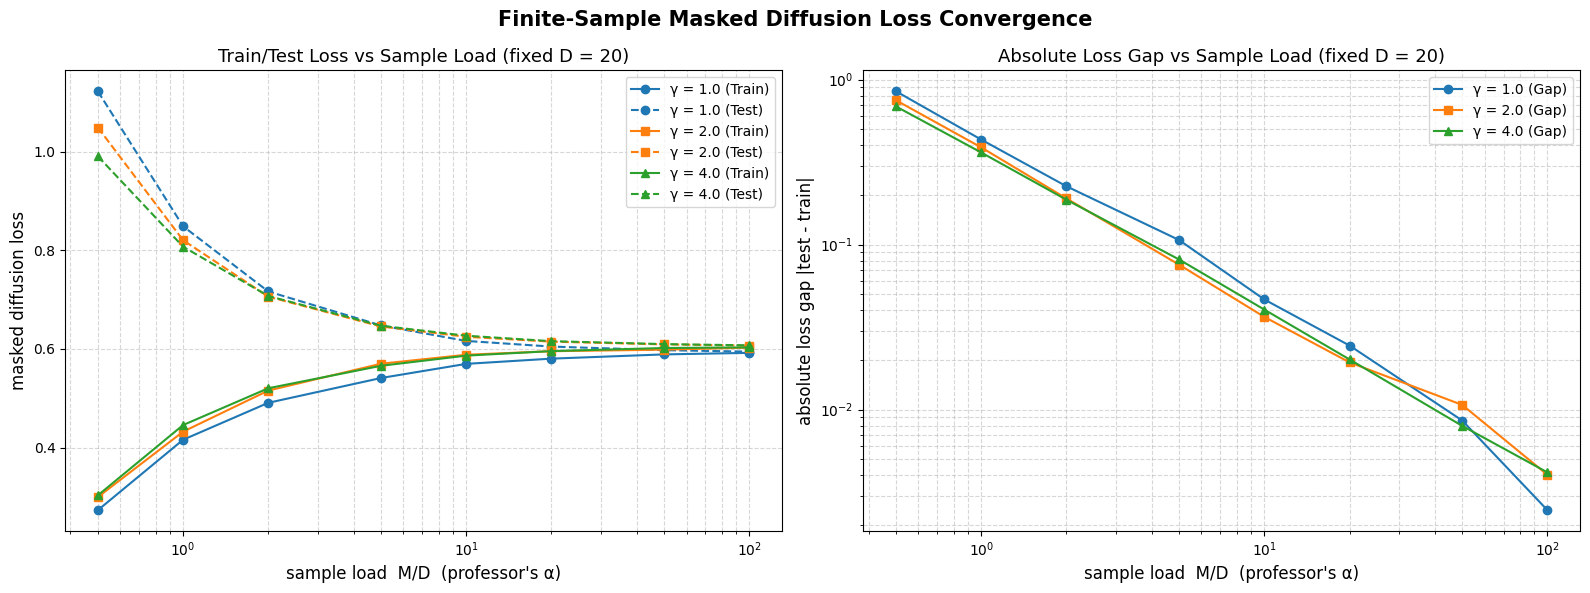

In [7]:
# Generate the unified convergence plots grouped by gamma (loss curves and gap plot)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define colors and markers for each gamma value
colors = {1.0: "#1f77b4", 2.0: "#ff7f0e", 4.0: "#2ca02c"}
markers = {1.0: "o", 2.0: "s", 4.0: "^"}

for gamma in gamma_values:
    sub_df = df[df["gamma"] == gamma]
    if sub_df.empty:
        continue
    color = colors.get(gamma, "#7f7f7f")
    marker = markers.get(gamma, "d")
    
    # --- Subplot 1: Train & Test Loss ---
    # Plot Train Loss (solid line)
    axes[0].plot(
        sub_df["sample_load"], 
        sub_df["train_loss"], 
        linestyle="-", 
        marker=marker, 
        color=color, 
        label=f"γ = {gamma:.1f} (Train)"
    )
    # Plot Test Loss (dashed line)
    axes[0].plot(
        sub_df["sample_load"], 
        sub_df["test_loss"], 
        linestyle="--", 
        marker=marker, 
        color=color, 
        label=f"γ = {gamma:.1f} (Test)"
    )
    
    # --- Subplot 2: Absolute Loss Gap ---
    axes[1].plot(
        sub_df["sample_load"], 
        sub_df["abs_loss_gap"], 
        linestyle="-", 
        marker=marker, 
        color=color, 
        label=f"γ = {gamma:.1f} (Gap)"
    )

# Formatting Subplot 1 (Losses)
axes[0].set_xscale("log")
axes[0].set_xlabel("sample load  M/D  (professor's α)", fontsize=12)
axes[0].set_ylabel("masked diffusion loss", fontsize=12)
axes[0].set_title("Train/Test Loss vs Sample Load (fixed D = 20)", fontsize=13)
axes[0].grid(True, which="both", linestyle="--", alpha=0.5)
axes[0].legend(loc="best")

# Formatting Subplot 2 (Loss Gap)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("sample load  M/D  (professor's α)", fontsize=12)
axes[1].set_ylabel("absolute loss gap |test - train|", fontsize=12)
axes[1].set_title("Absolute Loss Gap vs Sample Load (fixed D = 20)", fontsize=13)
axes[1].grid(True, which="both", linestyle="--", alpha=0.5)
axes[1].legend(loc="best")

plt.suptitle("Finite-Sample Masked Diffusion Loss Convergence", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("loss_convergence_grouped.png", bbox_inches="tight")
plt.show()


## Interpretation

At fixed latent dimension $D$ and visible-to-latent ratio $\gamma$, increasing the sample load $M_{\mathrm{train}}/D$ reduces the train/test discrepancy. 

Empirically, in this finite setup, the plots show that:
- A small sample load $M_{\mathrm{train}}/D$ (small sample-load / finite-sample regime) yields an optimistic (lower) training loss and a pessimistic (higher) held-out test loss estimate.
- A larger sample load $M_{\mathrm{train}}/D$ drives the train and test loss curves closer to each other, making the empirical training loss closer to the held-out test loss estimate.

Here, convergence refers to the empirical train and held-out test loss curves approaching each other as $M_{\mathrm{train}}/D$ increases. This is a finite-dimensional empirical sanity check, using the repository's absorbing-mask binary cross-entropy objective.
